<a href="https://colab.research.google.com/github/Bredalis/Cats-And-Dogs-Classification/blob/master/Cats_And_Dogs_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Libraries
import os
import random

import kagglehub
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Data preparation
dataset = kagglehub.dataset_download("marquis03/cats-and-dogs")


# Image processing
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset + "/train",
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    dataset + "/val",
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

100%|██████████| 9.75M/9.75M [00:01<00:00, 5.46MB/s]

Extracting files...


Found 220 images belonging to 2 classes.
Found 13 images belonging to 2 classes.


In [3]:
# Model creation
model = models.Sequential([
    # First convolutional layer
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Third convolutional layer
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPool2D(2, 2),

    # Convert feature maps into a vector
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Compile model
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [5]:
# Training
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 882ms/step - accuracy: 0.5538 - loss: 1.0647 - val_accuracy: 0.6923 - val_loss: 0.6369
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - accuracy: 0.6907 - loss: 0.6528 - val_accuracy: 0.6923 - val_loss: 0.6366
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.6344 - loss: 0.6598 - val_accuracy: 0.6923 - val_loss: 0.6244
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 373ms/step - accuracy: 0.6707 - loss: 0.6466 - val_accuracy: 0.6923 - val_loss: 0.6294
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.6839 - loss: 0.6358 - val_accuracy: 0.6923 - val_loss: 0.6150
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.6553 - loss: 0.6293 - val_accuracy: 0.6923 - val_loss: 0.5996
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.6461 - loss: 0.6198 - val_accuracy: 0.6923 - val_loss: 0.6080
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.6360 - loss: 0.6211 - val_accuracy: 0.6923 - val_loss

In [6]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,485,445 (55.26 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,656,964 (36.84 MB)

None


In [7]:
# Predictions
print(os.listdir(dataset))

val_cat = os.listdir(dataset + "/val/cat")
val_dog = os.listdir(dataset + "/val/dog")

val_cat = [dataset + "/val/cat/" + i for i in val_cat]
val_dog = [dataset + "/val/dog/" + i for i in val_dog]

for i, j in zip(val_cat, val_dog):
    print(f"{i} - {j}")

val_cat_example = random.sample(val_cat, 8)
val_dog_example = random.sample(val_dog, 8)
imgs = val_cat_example + val_dog_example
imgs = random.sample(imgs, 8)

print(imgs)

['val.csv', 'train', 'train.csv', 'val']
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/cat/Sphynx_104_jpg.rf.e7cb65a6212f786130b1bf1bf6d114a1.jpg - /root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/dog/havanese_144_jpg.rf.d3e2e8cb9a7801e61894e372c4f1e1bb.jpg
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/cat/Birman_137_jpg.rf.dc638a7840b71bfdcc9da6ce40ebdd36.jpg - /root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/dog/great_pyrenees_125_jpg.rf.f520612ef70685f46bdaa11fb5da2744.jpg
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/cat/Egyptian_Mau_152_jpg.rf.f08eb5fe066bbad4615280873336afb7.jpg - /root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/dog/english_cocker_spaniel_157_jpg.rf.f3dda6bc7163efd87e191af1ef6457d5.jpg
/root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2/val/cat/British_Shorthair_103_jpg.rf.ea9c679aa43c2bcc2dd74e51588f0c5e.jpg 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
0.55558
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
0.9992268
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
0.1302949
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
0.075047806
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
0.8674799
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
0.86235154
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
0.8202829
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
0.9999995


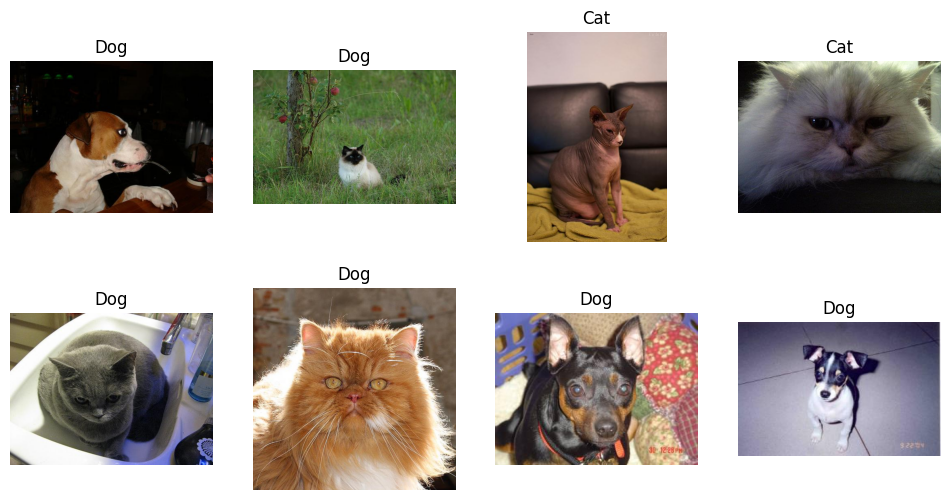

In [8]:
# Classification results plot

# Create 2x4 figure
plt.figure(figsize=(12, 6))

for i in range(8):
    img = image.load_img(imgs[i], target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    print(pred[0][0])

    plt.subplot(2, 4, i + 1)
    plt.imshow(mpimg.imread(imgs[i]))
    plt.title("Dog" if pred[0][0] > 0.5 else "Cat")
    plt.axis("off")

plt.show()